In [5]:
# Standard library
import os
import operator
from typing import TypedDict, Literal, Annotated, List
import requests

# Environment
from dotenv import load_dotenv

# LangChain
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

# LangGraph
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# Pinecone
from pinecone import Pinecone

# External
from tavily import TavilyClient

C:\Users\Parth\AppData\Local\Temp\ipykernel_18948\363456911.py:17: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


### loading all api keys from env file

In [6]:
load_dotenv()

MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
JINA_API_KEY = os.getenv("JINA_API_KEY")

### setting up llm model embedding model and vector db

In [7]:
# LLM models
llm_small = ChatMistralAI(model="mistral-small-latest", api_key=MISTRAL_API_KEY, temperature=0)
llm_large = ChatMistralAI(model="mistral-large-latest", api_key=MISTRAL_API_KEY, temperature=0)

# Embeddings
embeddings = MistralAIEmbeddings(model="mistral-embed", api_key=MISTRAL_API_KEY)

# Pinecone connection
pc = Pinecone(api_key=PINECONE_API_KEY)
index = pc.Index("rag-chatbot")

# Pinecone vector store
vectorstore = PineconeVectorStore(
    index=index,
    embedding=embeddings,
    text_key="text"
)

In [61]:
import os
from dotenv import load_dotenv, find_dotenv
from supabase import create_client

load_dotenv(find_dotenv())

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")
SUPABASE_BUCKET = os.getenv("SUPABASE_BUCKET")

print(f"URL loaded: {SUPABASE_URL is not None}")
print(f"Key loaded: {SUPABASE_KEY is not None}")
print(f"Bucket name: {SUPABASE_BUCKET}")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Client created successfully.")

URL loaded: True
Key loaded: True
Bucket name: pnx-ai-documents
Client created successfully.


### defining states

In [8]:
class AgentState(TypedDict):

    # Input
    query_type: Literal["rag", "chat", "web"]
    question: str
    chat_history: List[dict]

    # Query processing
    rewritten_query: str
    
    # multiple query
    all_queries: List[str]

    # Retrieval
    documents: List[Document]
    top_docs : list[dict]
    context: str
    retrieval_score: float
    retrieval_retry_count: 0

    # Generation
    answer: str
    hallucination_retry_count: 0
    hallucination_pass: bool

    # Grading
    answer_score: float

    # Final
    sources: List[str]
    final_answer: str

### making pdf loader that store pdf on vector db

In [73]:
def upload_pdf_to_supabase(filename: str, thread_id: str) -> str:
    """Upload the original PDF file to Supabase Storage, return its storage path"""
    storage_path = f"{thread_id}/{os.path.basename(filename)}"

    with open(filename, "rb") as f:
        supabase.storage.from_(SUPABASE_BUCKET).upload(
            path=storage_path,
            file=f.read(),
            file_options={"content-type": "application/pdf", "upsert": "true"}
        )

    return storage_path


def load_split_pdf(filename: str, thread_id: str):
    # 1. Upload original PDF to Supabase Storage
    pdf_path = upload_pdf_to_supabase(filename, thread_id)

    # 2. Load locally for ingestion
    loader = PyPDFLoader(filename)
    docs = loader.load()

    # 3. Split
    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    chunks = splitter.split_documents(docs)

    # 4. Add metadata
    for chunk in chunks:
        chunk.metadata["thread_id"] = thread_id
        chunk.metadata["pdf_path"] = pdf_path

    # 5. Store in Pinecone
    vectorstore.add_documents(chunks)

    print(f"Uploaded PDF to Supabase: {pdf_path}")
    print(f"Pushed {len(chunks)} chunks to Pinecone")

    return pdf_path

In [74]:
pdf_path = load_split_pdf("Popular CNN Architectures.pdf", thread_id="test-summary-1")
print(f"Stored at: {pdf_path}")

Uploaded PDF to Supabase: test-summary-1/Popular CNN Architectures.pdf
Pushed 8 chunks to Pinecone
Stored at: test-summary-1/Popular CNN Architectures.pdf


In [75]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def map_reduce_summarize(full_text: str) -> str:
    section_splitter = RecursiveCharacterTextSplitter(chunk_size=8000, chunk_overlap=200)
    sections = section_splitter.split_text(full_text)

    print(f"Document split into {len(sections)} section(s) for summarization")

    map_prompt = ChatPromptTemplate.from_messages([
        ("system", "Summarize the following section of a document. Be concise but capture all key points, names, and facts mentioned."),
        ("human", "{section}")
    ])
    map_chain = map_prompt | llm_large  # using llm_large — summarization benefits from stronger reasoning

    section_summaries = []
    for i, section in enumerate(sections):
        try:
            result = map_chain.invoke({"section": section})
            section_summaries.append(result.content)
            print(f"Summarized section {i+1}/{len(sections)}")
        except Exception as e:
            print(f"Failed to summarize section {i+1}: {e}")
            # Skip this section rather than failing the whole summary

    if not section_summaries:
        return "Sorry, I couldn't generate a summary due to repeated errors. Please try again shortly."

    if len(section_summaries) == 1:
        return section_summaries[0]

    combined = "\n\n".join(section_summaries)
    reduce_prompt = ChatPromptTemplate.from_messages([
        ("system", "The following are summaries of different sections of the same document. Combine them into one single, coherent, well-organized summary of the entire document."),
        ("human", "{combined_summaries}")
    ])
    reduce_chain = reduce_prompt | llm_large

    try:
        final_result = reduce_chain.invoke({"combined_summaries": combined})
        return final_result.content
    except Exception as e:
        print(f"Failed to combine summaries: {e}")
        # Fallback: return the individual section summaries joined together, rather than nothing
        return "\n\n---\n\n".join(section_summaries)

In [78]:
def get_pdf_path_for_thread(thread_id: str) -> str:
    """Find the original PDF's Supabase path for a given thread_id"""
    results = vectorstore.similarity_search(
        "summary",  # dummy query, we only care about metadata here
        k=1,
        filter={"thread_id": thread_id}
    )
    if not results:
        return None
    return results[0].metadata.get("pdf_path")

In [79]:
def download_pdf_from_supabase(storage_path: str, local_path: str = "temp_summary.pdf"):
    """Download a PDF from Supabase Storage to a local temp file"""
    response = supabase.storage.from_(SUPABASE_BUCKET).download(storage_path)
    with open(local_path, "wb") as f:
        f.write(response)
    return local_path

In [81]:
def summary_node(thread_id: str) -> str:
    pdf_path = get_pdf_path_for_thread(thread_id)
    if not pdf_path:
        return "No document found for this conversation."

    local_file = download_pdf_from_supabase(pdf_path)
    loader = PyPDFLoader(local_file)
    docs = loader.load()
    full_text = "\n\n".join([d.page_content for d in docs])

    return map_reduce_summarize(full_text)

In [82]:
summary = summary_node("test-summary-1")
print(summary)

Document split into 1 section(s) for summarization
Summarized section 1/1
### **Summary: Popular CNN Architectures**

#### **Pre-trained CNN Overview**
- A **pre-trained CNN** is a model pre-trained on large datasets (e.g., ImageNet) with reusable weights for tasks like classification, detection, or feature extraction.
- **Key advantages**: Saves time/compute, enables **transfer learning**.
- **Normal CNNs**: Shallow, trained from scratch on small datasets.
- **Pre-trained CNNs**: Deeper, trained on large datasets, use innovative blocks (e.g., Inception, residual connections) and tricks (skip connections, separable convolutions).

---

#### **Popular CNN Architectures**

1. **LeNet-5 (1998)**
   - Early CNN for digit recognition.
   - Structure: Conv + pooling + tanh + fully connected (FC) layers.
   - **Key difference**: Shallower than modern CNNs.

2. **AlexNet (2012)**
   - First deep CNN to win **ImageNet** (proved deep learning’s power).
   - Structure: 5 conv + 3 FC layers, **ReL

### Checking query if query belongs to rag or general chat

In [18]:
def query_analyzer(state: AgentState) -> AgentState:
    """Classify query as 'rag', 'chat' or 'web'"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a query classifier. Classify the user query into one of three categories:
- 'rag': if the query requires searching uploaded documents or PDFs
- 'chat': if the query is general knowledge, concepts, definitions or simple questions
- 'web': if the query requires current information, latest news, recent events, or real-time data

Respond with ONLY one word: 'rag', 'chat' or 'web'. Nothing else."""),
        ("human", "{question}")
    ])

    chain = prompt | llm_small
    result = chain.invoke({"question": state["question"]})
    query_type = result.content.strip().lower()

    if query_type not in ["rag", "chat", "web"]:
        query_type = "rag"

    print(f"Query type: {query_type}")

    return {"query_type": query_type, "question": state["question"]}

In [19]:
result = query_analyzer({"question": "what is corrective retrieval augmented generation in this pdf?"})
print(result)

Query type: rag
{'query_type': 'rag', 'question': 'what is corrective retrieval augmented generation in this pdf?'}


### llm use our query and make query more useful better so llm understand query properly so we get better retrieval answer

In [20]:
def query_rewriter(state: AgentState) -> AgentState:
    """Rewrite the user query for better retrieval"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert query rewriter for a RAG system.
Rewrite the user's question to be more specific and retrieval-friendly.
Keep it concise - one clear sentence only.
Do NOT add multiple options or examples.
Return ONLY the rewritten query. Nothing else."""),
        ("human", "Original question: {question}")
    ])

    chain = prompt | llm_small
    result = chain.invoke({"question": state["question"]})
    rewritten = result.content.strip()

    print(f"Original: {state['question']}")
    print(f"Rewritten: {rewritten}")

    return {"rewritten_query": rewritten, "question": state["question"]}

In [21]:
result = query_rewriter({"question": "what is corrective retrieval augmented generation? in this pdf?"})
print(result)

Original: what is corrective retrieval augmented generation? in this pdf?
Rewritten: What is the definition and explanation of Corrective Retrieval Augmented Generation (CRAG) in this PDF?
{'rewritten_query': 'What is the definition and explanation of Corrective Retrieval Augmented Generation (CRAG) in this PDF?', 'question': 'what is corrective retrieval augmented generation? in this pdf?'}


### if query type is chat then llm directly answer the question without searching documents

In [22]:
def chat_node(state: AgentState) -> AgentState:
    """Directly answer general chat questions without RAG"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant. Answer the user's question clearly and concisely."),
        ("human", "{question}")
    ])

    chain = prompt | llm_large
    result = chain.invoke({"question": state["question"]})
    answer = result.content.strip()

    print(f"Chat answer: {answer}")

    return {"final_answer": answer}

In [23]:
result = chat_node({"question": "what is attention mechanism"})
print(result)

Chat answer: The **attention mechanism** is a technique in deep learning that allows models to focus on the most relevant parts of the input data when producing an output. It mimics human cognitive attention by dynamically weighting different parts of the input, improving performance in tasks like:

### **Key Features:**
1. **Dynamic Weighting** – Assigns importance scores to input elements (e.g., words in a sentence).
2. **Context-Aware** – Captures relationships between distant elements (e.g., long-range dependencies in text).
3. **Interpretability** – Highlights which parts of the input influenced the output.

### **Types of Attention:**
- **Self-Attention** (e.g., in Transformers): Relates different positions of a single sequence to compute a representation.
- **Cross-Attention**: Links two different sequences (e.g., in machine translation).
- **Multi-Head Attention**: Uses multiple attention layers in parallel for richer representations.

### **Applications:**
- **NLP** (e.g., mac

### Now build the web_search_node — for "web" type queries. This uses Tavily to search and then generates an answer from web results.

In [24]:
def web_search_node(state: AgentState) -> AgentState:
    """Search web for current information and generate answer"""

    client = TavilyClient(api_key=TAVILY_API_KEY)

    results = client.search(
        query=state["question"],
        max_results=5
    )

    # Build context from web results
    context = ""
    sources = []
    for i, r in enumerate(results["results"]):
        context += f"[Result {i+1}]\n{r['content']}\n\n"
        sources.append(r["url"])

    # Generate answer from web context
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant. Answer the user's question based on the provided web search results.
Be accurate and cite which result supports your answer."""),
        ("human", """Web Search Results:
{context}

Question: {question}""")
    ])

    chain = prompt | llm_large
    result = chain.invoke({
        "context": context,
        "question": state["question"]
    })

    answer = result.content.strip()

    # Add sources
    citation_text = "\n\n**Sources:**"
    for i, source in enumerate(sources):
        citation_text += f"\n[{i+1}] {source}"

    final_answer = answer + citation_text

    print(f"Web search answer generated ")

    return {"final_answer": final_answer}

In [25]:
result2 = {"question": "what is the latest news in AI today?", "query_type": "web"}
result2.update(web_search_node(result2))
print(result2["final_answer"])

Web search answer generated 
Here are some of the latest news highlights in AI based on the provided search results:

1. **OpenAI’s Massive Cloud Spending Plans**
   OpenAI is reportedly planning to spend up to **$750 billion** on cloud computing as part of its efforts to ramp up AI infrastructure. This includes a **$500 billion commitment** to invest in advanced AI platforms in the U.S. *(Result 1)*

2. **Leadership Changes at OpenAI**
   - **OpenAI’s Head of Safety** is leaving the company. *(Result 3)*
   - **Fidji Simo, CEO of AGI Deployment**, is stepping down. *(Result 3)*
   - **Apple is suing OpenAI**, alleging the company stole hardware secrets. *(Result 3)*

3. **China’s AI Ambitions and Challenges**
   - Chinese AI companies are rushing to raise funds and close the gap with U.S. firms, but a **shortage of investment and chips** is holding them back. *(Result 1)*
   - At the **World Artificial Intelligence Conference in China**, Xi Jinping emphasized AI as a key diplomatic to

### llm use our rewritten query and make 1 query into 3 query so we can get multiple answer based on that quer

In [26]:
def multi_query_generator(state: AgentState) -> AgentState:
    """Generate multiple query variations for better retrieval"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert at generating query variations for a RAG system.
Generate exactly 3 different variations of the given query.
Each variation should be semantically similar but worded differently.
Return ONLY the 3 queries separated by | character.
Example format: query one | query two | query three
Nothing else."""),
        ("human", "Query: {rewritten_query}")
    ])

    chain = prompt | llm_small
    result = chain.invoke({"rewritten_query": state["rewritten_query"]})

    # Simple clean parsing
    queries = [q.strip() for q in result.content.strip().split("|") if q.strip()]

    # Always include the rewritten query itself
    all_queries = [state["rewritten_query"]] + queries

    print(f"Generated {len(all_queries)} queries:")
    for q in all_queries:
        print(f"  - {q}")

    return {"all_queries": all_queries, "rewritten_query": state["rewritten_query"]}

In [27]:
result = query_analyzer({"question": "what is corrective retrieval augmented generation in this pdf?"})
result.update(query_rewriter(result))
result.update(multi_query_generator(result))
print(result)

Query type: rag
Original: what is corrective retrieval augmented generation in this pdf?
Rewritten: What is the definition and explanation of Corrective Retrieval Augmented Generation (CRAG) as described in this PDF?
Generated 4 queries:
  - What is the definition and explanation of Corrective Retrieval Augmented Generation (CRAG) as described in this PDF?
  - What does Corrective Retrieval Augmented Generation (CRAG) mean and how is it explained in the provided PDF?
  - Can you provide the definition and a detailed explanation of Corrective Retrieval Augmented Generation (CRAG) as outlined in the PDF?
  - How is Corrective Retrieval Augmented Generation (CRAG) defined and explained in the document?
{'query_type': 'rag', 'question': 'what is corrective retrieval augmented generation in this pdf?', 'rewritten_query': 'What is the definition and explanation of Corrective Retrieval Augmented Generation (CRAG) as described in this PDF?', 'all_queries': ['What is the definition and explanat

### now making retriever it fetch all multiple query is generated by the multiple query generator and gives answer

In [28]:
def retrieve_documents(state: AgentState) -> AgentState:
    """Retrieve documents from Pinecone for all queries"""

    all_docs = []
    for query in state["all_queries"]:
        docs = vectorstore.similarity_search(query, k=5)
        all_docs.extend(docs)

    print(f"Retrieved {len(all_docs)} chunks total")

    return {"documents": all_docs, "all_queries": state["all_queries"]}

In [29]:
result.update(retrieve_documents(result))
print(f"Total chunks: {len(result['documents'])}")

Retrieved 20 chunks total
Total chunks: 20


### llm check our retrieved documents are relevant to the question or not and give score

In [30]:
def grade_retrieval(state: AgentState) -> AgentState:
    """Grade the relevance of retrieved documents"""

    docs_sample = state["documents"][:5]
    docs_content = "\n\n".join([doc.page_content[:500] for doc in docs_sample])

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a retrieval grader.
Judge whether the retrieved documents are relevant to answer the user's question.
Give a score from 0 to 5:
- 0-2: Documents are not relevant at all
- 3-5: Documents are relevant and useful

Return ONLY a single number between 0 and 5. Nothing else."""),
        ("human", """Question: {question}

Retrieved Documents:
{documents}""")
    ])

    chain = prompt | llm_small
    result = chain.invoke({
        "question": state["question"],
        "documents": docs_content
    })

    try:
        score = float(result.content.strip())
    except:
        score = 3.0

    print(f"Retrieval score: {score}")

    return {"retrieval_score": score}

In [31]:
result.update(retrieve_documents(result))
result.update(grade_retrieval(result))
print(result["retrieval_score"])

Retrieved 20 chunks total
Retrieval score: 0.0
0.0


### refine node works when retrieval score is less than 3 then it loops back to the query rewriter it loops back max attempts 3 times

In [32]:
def refine_query(state: AgentState) -> AgentState:
    """Refine the query when retrieval score is low"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert at reformulating search queries.
The previous query did not retrieve relevant documents.
Generate a completely different version of the query using different keywords and angle.
Return ONLY the new query. Nothing else."""),
        ("human", """Original question: {question}
Previous query that failed: {rewritten_query}""")
    ])

    chain = prompt | llm_small
    result = chain.invoke({
        "question": state["question"],
        "rewritten_query": state["rewritten_query"]
    })

    new_query = result.content.strip()
    new_retry_count = state["retrieval_retry_count"] + 1

    print(f"Refined query: {new_query}")
    print(f"Retry count: {new_retry_count}")

    return {
    "rewritten_query": new_query,
    "retrieval_retry_count": new_retry_count,
    "documents": [],
    "all_queries": []
}

In [33]:
result["retrieval_retry_count"] = 0
result.update(refine_query(result))
print(result["rewritten_query"])

Refined query: Explanation of Corrective Retrieval Augmented Generation (CRAG) in this document
Retry count: 1
Explanation of Corrective Retrieval Augmented Generation (CRAG) in this document


### if max count reached that means vector db has no answer regarding our query so
### then query go to the tavily and search the answer of it

In [34]:

def tavily_search(state: AgentState) -> AgentState:
    """Fallback web search when Pinecone retrieval fails"""

    client = TavilyClient(api_key=TAVILY_API_KEY)

    results = client.search(
        query=state["question"],
        max_results=5
    )

    # Convert Tavily results to Document format
    docs = []
    for r in results["results"]:
        doc = Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")}
        )
        docs.append(doc)

    print(f"Tavily retrieved {len(docs)} web results")

    return {"documents": docs}

In [35]:
result.update(tavily_search(result))
print(f"Total web docs: {len(result['documents'])}")
print(f"First result source: {result['documents'][0].metadata['source']}")

Tavily retrieved 5 web results
Total web docs: 5
First result source: https://arxiv.org/pdf/2401.15884


### now we are going to add reranker node that is going to rearrange in order the the retrival gived answer so get better answer and wrong answer got negleted

In [36]:
def reranker(state: AgentState) -> AgentState:
    """Rerank retrieved documents using Jina Reranker API"""

    documents = state["documents"]
    doc_texts = [doc.page_content for doc in documents]

    response = requests.post(
        "https://api.jina.ai/v1/rerank",
        headers={"Authorization": f"Bearer {JINA_API_KEY}", "Content-Type": "application/json"},
        json={"model": "jina-reranker-v3", "query": state["rewritten_query"], "documents": doc_texts, "top_n": 5}
    )

    data = response.json()
    top_docs = []

    for item in data["results"]:
        doc = documents[item["index"]]
        top_docs.append({
            "content": doc.page_content,
            "source": doc.metadata.get("source", ""),
            "score": item["relevance_score"]
        })

    print(f"Top {len(top_docs)} chunks after reranking:")
    for d in top_docs:
        print(f"  Score: {d['score']:.4f}")

    return {"top_docs": top_docs}

In [37]:
result.update(reranker(result))

Top 5 chunks after reranking:
  Score: 0.3935
  Score: 0.2205
  Score: 0.1156
  Score: 0.1100
  Score: -0.1295


### now we add context builder who add all five chunks together and remove duplicate chunks and reorder highest chunk to top and join them into  clean text block

In [38]:
def context_builder(state: AgentState) -> AgentState:
    """Build clean context from top reranked documents"""

    top_docs = state["top_docs"]
    
    context = ""
    sources = []
    seen = set()

    for i, doc in enumerate(top_docs):
        # Skip duplicate chunks
        if doc["content"] in seen:
            continue
        seen.add(doc["content"])
        
        context += f"[Chunk {i+1}]\n{doc['content']}\n\n"
        if doc["source"]:
            sources.append(doc["source"])

    print(f"Context built from {len(seen)} unique chunks")
    print(f"Total characters: {len(context)}")

    return {
        "context": context,
        "sources": sources
    }

In [39]:
result.update(context_builder(result))
print(result["context"][:500])

Context built from 5 unique chunks
Total characters: 4835
[Chunk 1]
Al-though retrieval-augmented generation (RAG) is a practicable complement to LLMs, it relies heavily on the relevance of retrieved docu-ments, raising concerns about how the model behaves if retrieval goes wrong. To this end, we propose the Corrective Retrieval Augmented Generation (CRAG) to improve the robustness of generation. Specifically, a lightweight retrieval evaluator is designed to assess the overall quality of retrieved documents for a query, returning a confidence degree ba


In [40]:
def answer_generator(state: AgentState) -> AgentState:
    """Generate answer from context using mistral-large"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant. Answer the user's question based ONLY on the provided context.
If the context doesn't contain enough information, say "I don't have enough information to answer this."
Be clear, concise and accurate."""),
        ("human", """Context:
{context}

Question: {question}""")
    ])

    chain = prompt | llm_large
    result = chain.invoke({
        "context": state["context"],
        "question": state["question"]
    })

    answer = result.content.strip()
    print(f"Answer generated: {answer[:200]}...")

    return {"answer": answer}

In [41]:
result.update(answer_generator(result))
print(result["answer"])

Answer generated: Based on the provided context, **Corrective Retrieval Augmented Generation (CRAG)** is an advanced framework within the Retrieval-Augmented Generation (RAG) paradigm that improves the robustness and a...
Based on the provided context, **Corrective Retrieval Augmented Generation (CRAG)** is an advanced framework within the Retrieval-Augmented Generation (RAG) paradigm that improves the robustness and accuracy of language model outputs by:

1. **Assessing retrieved documents**: A lightweight retrieval evaluator grades the relevance of documents for a given query and assigns a confidence degree.
2. **Triggering corrective actions**: Based on the confidence score, it may refine retrieval results or augment them with large-scale web searches to compensate for sub-optimal static corpora.
3. **Self-correcting mechanism**: It incorporates self-reflection and iterative refinement to enhance the quality of retrieved knowledge before generation.
4. **Integration with web search*

In [42]:
def hallucination_check(state: AgentState) -> AgentState:
    """Check if answer is grounded in context"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a hallucination checker.
Check if the answer is fully grounded in the provided context.
If everything in the answer is supported by the context, respond with 'pass'.
If the answer contains information not present in the context, respond with 'fail'.
Respond with ONLY one word: 'pass' or 'fail'. Nothing else."""),
        ("human", """Context : {context}
        
Answer:
{answer}""")
    ])
    chain = prompt | llm_small
    result = chain.invoke({
        "context": state["context"],
        "answer": state["answer"]
    })

    check = result.content.strip().lower()

    if check not in ["pass", "fail"]:
        check = "pass"

    hallucination_pass = check == "pass"
    print(f"Hallucination check: {check}")

    return {
        "hallucination_pass": hallucination_pass,
        "hallucination_retry_count": state["hallucination_retry_count"]
    }

In [43]:
result["hallucination_retry_count"] = 0
result.update(hallucination_check(result))
print(result["hallucination_pass"])

Hallucination check: pass
True


### now making loop for halucination if hallucination is comes then it goes through back to answer grader because llm is genrated hallucinated answer so

In [44]:
def regenerate(state: AgentState) -> AgentState:
    """Regenerate answer with stricter prompt when hallucination detected"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a strict assistant. Answer ONLY using the provided context.
Do NOT add any information that is not explicitly present in the context.
Do NOT make assumptions or inferences beyond what is written.
If the context doesn't contain the answer, say "I don't have enough information." """),
        ("human", """Context:
{context}

Question: {question}""")
    ])

    chain = prompt | llm_large
    result = chain.invoke({
        "context": state["context"],
        "question": state["question"]
    })

    new_count = state["hallucination_retry_count"] + 1
    answer = result.content.strip()

    print(f"Regenerated answer (attempt {new_count})")
    print(f"Answer: {answer[:200]}...")

    return {
        "answer": answer,
        "hallucination_retry_count": new_count
    }

In [45]:
result["hallucination_retry_count"] = 0
result.update(regenerate(result))
print(result["hallucination_retry_count"])

Regenerated answer (attempt 1)
Answer: Corrective Retrieval Augmented Generation (CRAG) is an advanced framework within the Retrieval-Augmented Generation (RAG) approach that:

1. Improves the robustness of generation by assessing the qual...
1


### now answer is not hallucinated then answer goes through the answer grader that Takes the final answer and scores it on quality — relevance, completeness and accuracy — on a scale of 0 to 5.

In [46]:
def answer_grader(state: AgentState) -> AgentState:
    """Grade the quality of the generated answer"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an answer quality grader.
Grade the answer based on relevance, completeness and accuracy to the question.
Give a score from 0 to 5:
- 0-3: Answer is incomplete, irrelevant or inaccurate
- 4-5: Answer is relevant, complete and accurate

Return ONLY a single number between 0 and 5. Nothing else."""),
        ("human", """Question: {question}

Answer: {answer}""")
    ])

    chain = prompt | llm_small
    result = chain.invoke({
        "question": state["question"],
        "answer": state["answer"]
    })

    try:
        score = float(result.content.strip())
    except:
        score = 4.0

    print(f"Answer score: {score}")

    if score < 4:
        print("Score too low - restarting pipeline")
        return {
            "answer_score": score,
            "documents": [],
            "top_docs": [],
            "context": "",
            "answer": "",
            "retrieval_retry_count": 0,
            "hallucination_retry_count": 0,
            "all_queries": [],
            "sources": []
        }

    return {"answer_score": score}

In [47]:
result.update(answer_grader(result))
print(result["answer_score"])

Answer score: 5.0
5.0


### if Url availble in the source then it joins the url with our final answer 

In [48]:
def source_citation(state: AgentState) -> AgentState:
    """Format sources into clean citations"""

    sources = state["sources"]
    answer = state["answer"]

    if not sources:
        # No sources available — just return answer as is url availbe then give 
        return {"final_answer": answer}

    # Remove duplicates
    unique_sources = list(set(sources))

    # Build citation string
    citation_text = "\n\n**Sources:**"
    for i, source in enumerate(unique_sources):
        citation_text += f"\n[{i+1}] {source}"

    final_answer = answer + citation_text

    print(f"Added {len(unique_sources)} citations")

    return {"final_answer": final_answer}

In [49]:
result.update(source_citation(result))
print(result["final_answer"])

Added 5 citations
Corrective Retrieval Augmented Generation (CRAG) is an advanced framework within the Retrieval-Augmented Generation (RAG) approach that:

1. Improves the robustness of generation by assessing the quality of retrieved documents using a lightweight retrieval evaluator, which returns a confidence degree to trigger different knowledge retrieval actions.
2. Utilizes large-scale web searches to augment retrieval results when static or limited corpora return sub-optimal documents.
3. Incorporates mechanisms for self-reflection and self-grading of retrieved documents to enhance the accuracy and relevance of generated responses.
4. Integrates web search capabilities into its retrieval and generation processes to improve reliability.
5. Employs an iterative process to scrutinize and refine the output, offering more precise and contextually relevant responses.

**Sources:**
[1] https://www.analyticsvidhya.com/blog/2024/12/corrective-rag
[2] https://www.semanticscholar.org/paper/

### This is the last node in the pipeline. It simply takes final_answer from state and returns it as the output.

In [50]:
def final_response(state: AgentState) -> AgentState:
    """Return the final response"""

    print("Final answer ready ")
    print(state["final_answer"])

    return {"final_answer": state["final_answer"]}

In [51]:
result.update(final_response(result))

Final answer ready 
Corrective Retrieval Augmented Generation (CRAG) is an advanced framework within the Retrieval-Augmented Generation (RAG) approach that:

1. Improves the robustness of generation by assessing the quality of retrieved documents using a lightweight retrieval evaluator, which returns a confidence degree to trigger different knowledge retrieval actions.
2. Utilizes large-scale web searches to augment retrieval results when static or limited corpora return sub-optimal documents.
3. Incorporates mechanisms for self-reflection and self-grading of retrieved documents to enhance the accuracy and relevance of generated responses.
4. Integrates web search capabilities into its retrieval and generation processes to improve reliability.
5. Employs an iterative process to scrutinize and refine the output, offering more precise and contextually relevant responses.

**Sources:**
[1] https://www.analyticsvidhya.com/blog/2024/12/corrective-rag
[2] https://www.semanticscholar.org/pape

### now connecting making tree for our all nodes and all brances in our graph

In [52]:
# Initialize graph
workflow = StateGraph(AgentState)

# Add all nodes
workflow.add_node("query_analyzer", query_analyzer)
workflow.add_node("query_rewriter", query_rewriter)
workflow.add_node("multi_query_generator", multi_query_generator)
workflow.add_node("retrieve_documents", retrieve_documents)
workflow.add_node("grade_retrieval", grade_retrieval)
workflow.add_node("refine_query", refine_query)
workflow.add_node("tavily_search", tavily_search)
workflow.add_node("reranker", reranker)
workflow.add_node("context_builder", context_builder)
workflow.add_node("answer_generator", answer_generator)
workflow.add_node("hallucination_check", hallucination_check)
workflow.add_node("regenerate", regenerate)
workflow.add_node("answer_grader", answer_grader)
workflow.add_node("source_citation", source_citation)
workflow.add_node("final_response", final_response)
workflow.add_node("chat_node", chat_node)
workflow.add_node("web_search_node", web_search_node)

# Entry point
workflow.set_entry_point("query_analyzer")

# Simple edges
workflow.add_edge("query_rewriter", "multi_query_generator")
workflow.add_edge("multi_query_generator", "retrieve_documents")
workflow.add_edge("retrieve_documents", "grade_retrieval")
workflow.add_edge("refine_query", "query_rewriter")
workflow.add_edge("tavily_search", "reranker")
workflow.add_edge("reranker", "context_builder")
workflow.add_edge("context_builder", "answer_generator")
workflow.add_edge("answer_generator", "hallucination_check")
workflow.add_edge("regenerate", "answer_generator")
workflow.add_edge("source_citation", "final_response")
workflow.add_edge("final_response", END)
workflow.add_edge("chat_node", "final_response")
workflow.add_edge("web_search_node", "final_response")

In [53]:
# Conditional edge — query_analyzer
def route_query(state: AgentState) -> str:
    if state["query_type"] == "chat":
        return "chat_node"
    elif state["query_type"] == "web":
        return "web_search_node"
    else:
        return "query_rewriter"

workflow.add_conditional_edges("query_analyzer", route_query, {
    "chat_node": "chat_node",
    "web_search_node": "web_search_node",
    "query_rewriter": "query_rewriter"
})

# Conditional edge — grade_retrieval
def route_retrieval(state: AgentState) -> str:
    if state["retrieval_score"] >= 3:
        return "reranker"
    elif state["retrieval_retry_count"] >= 3:
        return "tavily_search"
    else:
        return "refine_query"

workflow.add_conditional_edges("grade_retrieval", route_retrieval, {
    "reranker": "reranker",
    "tavily_search": "tavily_search",
    "refine_query": "refine_query"
})

# Conditional edge — hallucination_check
def route_hallucination(state: AgentState) -> str:
    if state["hallucination_pass"]:
        return "answer_grader"
    elif state["hallucination_retry_count"] >= 2:
        return "answer_grader"
    else:
        return "regenerate"

workflow.add_conditional_edges("hallucination_check", route_hallucination, {
    "answer_grader": "answer_grader",
    "regenerate": "regenerate"
})

# Conditional edge — answer_grader
def route_answer(state: AgentState) -> str:
    if state["answer_score"] >= 4:
        return "source_citation"
    else:
        return "query_rewriter"

workflow.add_conditional_edges("answer_grader", route_answer, {
    "source_citation": "source_citation",
    "query_rewriter": "query_rewriter"
})


In [54]:
app = workflow.compile()

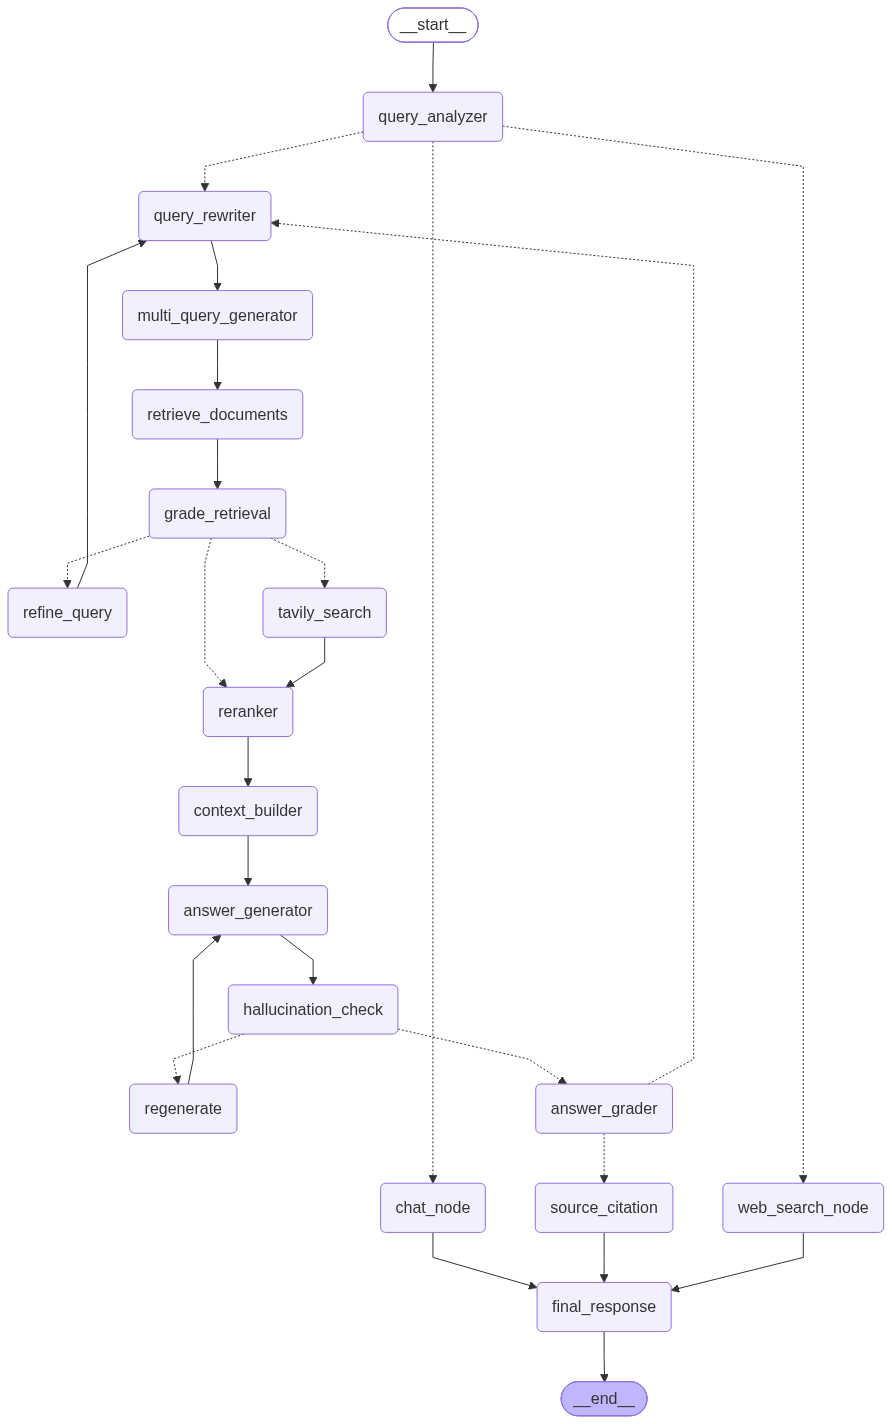

In [55]:
from IPython.display import Image, display
img = app.get_graph().draw_mermaid_png()
display(Image(img, width=600))

### testing the loops in the project is correctly working or not

In [56]:
test_input = {
    "question": "what are the side effects of paracetamol in this document?",
    "chat_history": [],
    "query_type": "rag",
    "rewritten_query": "",
    "all_queries": [],
    "documents": [],
    "top_docs": [],
    "context": "",
    "retrieval_score": 0.0,
    "retrieval_retry_count": 0,
    "answer": "",
    "hallucination_retry_count": 0,
    "hallucination_pass": False,
    "answer_score": 0.0,
    "sources": [],
    "final_answer": ""
}

result = app.invoke(test_input)
print(f"Retry count: {result['retrieval_retry_count']}")
print(f"Final answer: {result['final_answer'][:300]}")

Query type: rag
Original: what are the side effects of paracetamol in this document?
Rewritten: What are the documented side effects of paracetamol in this text?
Generated 4 queries:
  - What are the documented side effects of paracetamol in this text?
  - What documented adverse reactions does paracetamol have according to this text?
  - What side effects of paracetamol are mentioned in this document?
  - According to this text, what are the known side effects of taking paracetamol?
Retrieved 20 chunks total
Retrieval score: 0.0
Refined query: Paracetamol adverse reactions listed in this document
Retry count: 1
Original: what are the side effects of paracetamol in this document?
Rewritten: What are the documented side effects of paracetamol in this text?
Generated 4 queries:
  - What are the documented side effects of paracetamol in this text?
  - What documented adverse reactions does paracetamol have according to this text?
  - What side effects of paracetamol are mentioned in this 